# **LIBRARY**

In [ ]:
import torch

if torch.cuda.is_available():
    print('GPU aktif:', torch.cuda.get_device_name(0))
else:
    print('GPU tidak terdeteksi. Pastikan sudah ganti runtime ke GPU.')

GPU aktif: Tesla T4


In [ ]:
!pip install ultralytics -q
print('Ultralytics berhasil diinstall.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 71.2 MB/s eta 0:00:00
Ultralytics berhasil diinstall.


# **UPLOAD DATASET**

In [ ]:
from google.colab import files
import zipfile

uploaded = files.upload()

Saving phone.v1i.yolo26.zip to phone.v1i.yolo26.zip


In [ ]:
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/dataset')

print('Dataset berhasil diekstrak.')
!ls /content/dataset

Dataset berhasil diekstrak.
data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
yaml_content = """train: /content/dataset/train/images
val:   /content/dataset/valid/images
test:  /content/dataset/test/images

nc: 1
names: ['phone']
"""

with open('/content/dataset/data.yaml', 'w') as f:
    f.write(yaml_content)

print('data.yaml sudah diperbaiki.')
!cat /content/dataset/data.yaml

data.yaml sudah diperbaiki.
train: /content/dataset/train/images
val:   /content/dataset/valid/images
test:  /content/dataset/test/images

nc: 1
names: ['phone']


# **Cek Jumlah Dataset**

In [ ]:
import os

train = len(os.listdir('/content/dataset/train/images'))
valid = len(os.listdir('/content/dataset/valid/images'))
test  = len(os.listdir('/content/dataset/test/images'))

print('Jumlah Dataset:')
print(f'  Train    : {train} gambar')
print(f'  Validasi : {valid} gambar')
print(f'  Test     : {test} gambar')
print(f'  Total    : {train + valid + test} gambar')

Jumlah Dataset:
  Train    : 2296 gambar
  Validasi : 656 gambar
  Test     : 328 gambar
  Total    : 3280 gambar


# **Training**

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.yaml')

results = model.train(
    data     = '/content/dataset/data.yaml',
    epochs   = 150,
    imgsz    = 640,
    batch    = 16,
    device   = 'cuda',
    patience = 20,
    name     = 'ngawasin-scratch'
)

print('Training selesai.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=

# **Lihat Hasil Training**

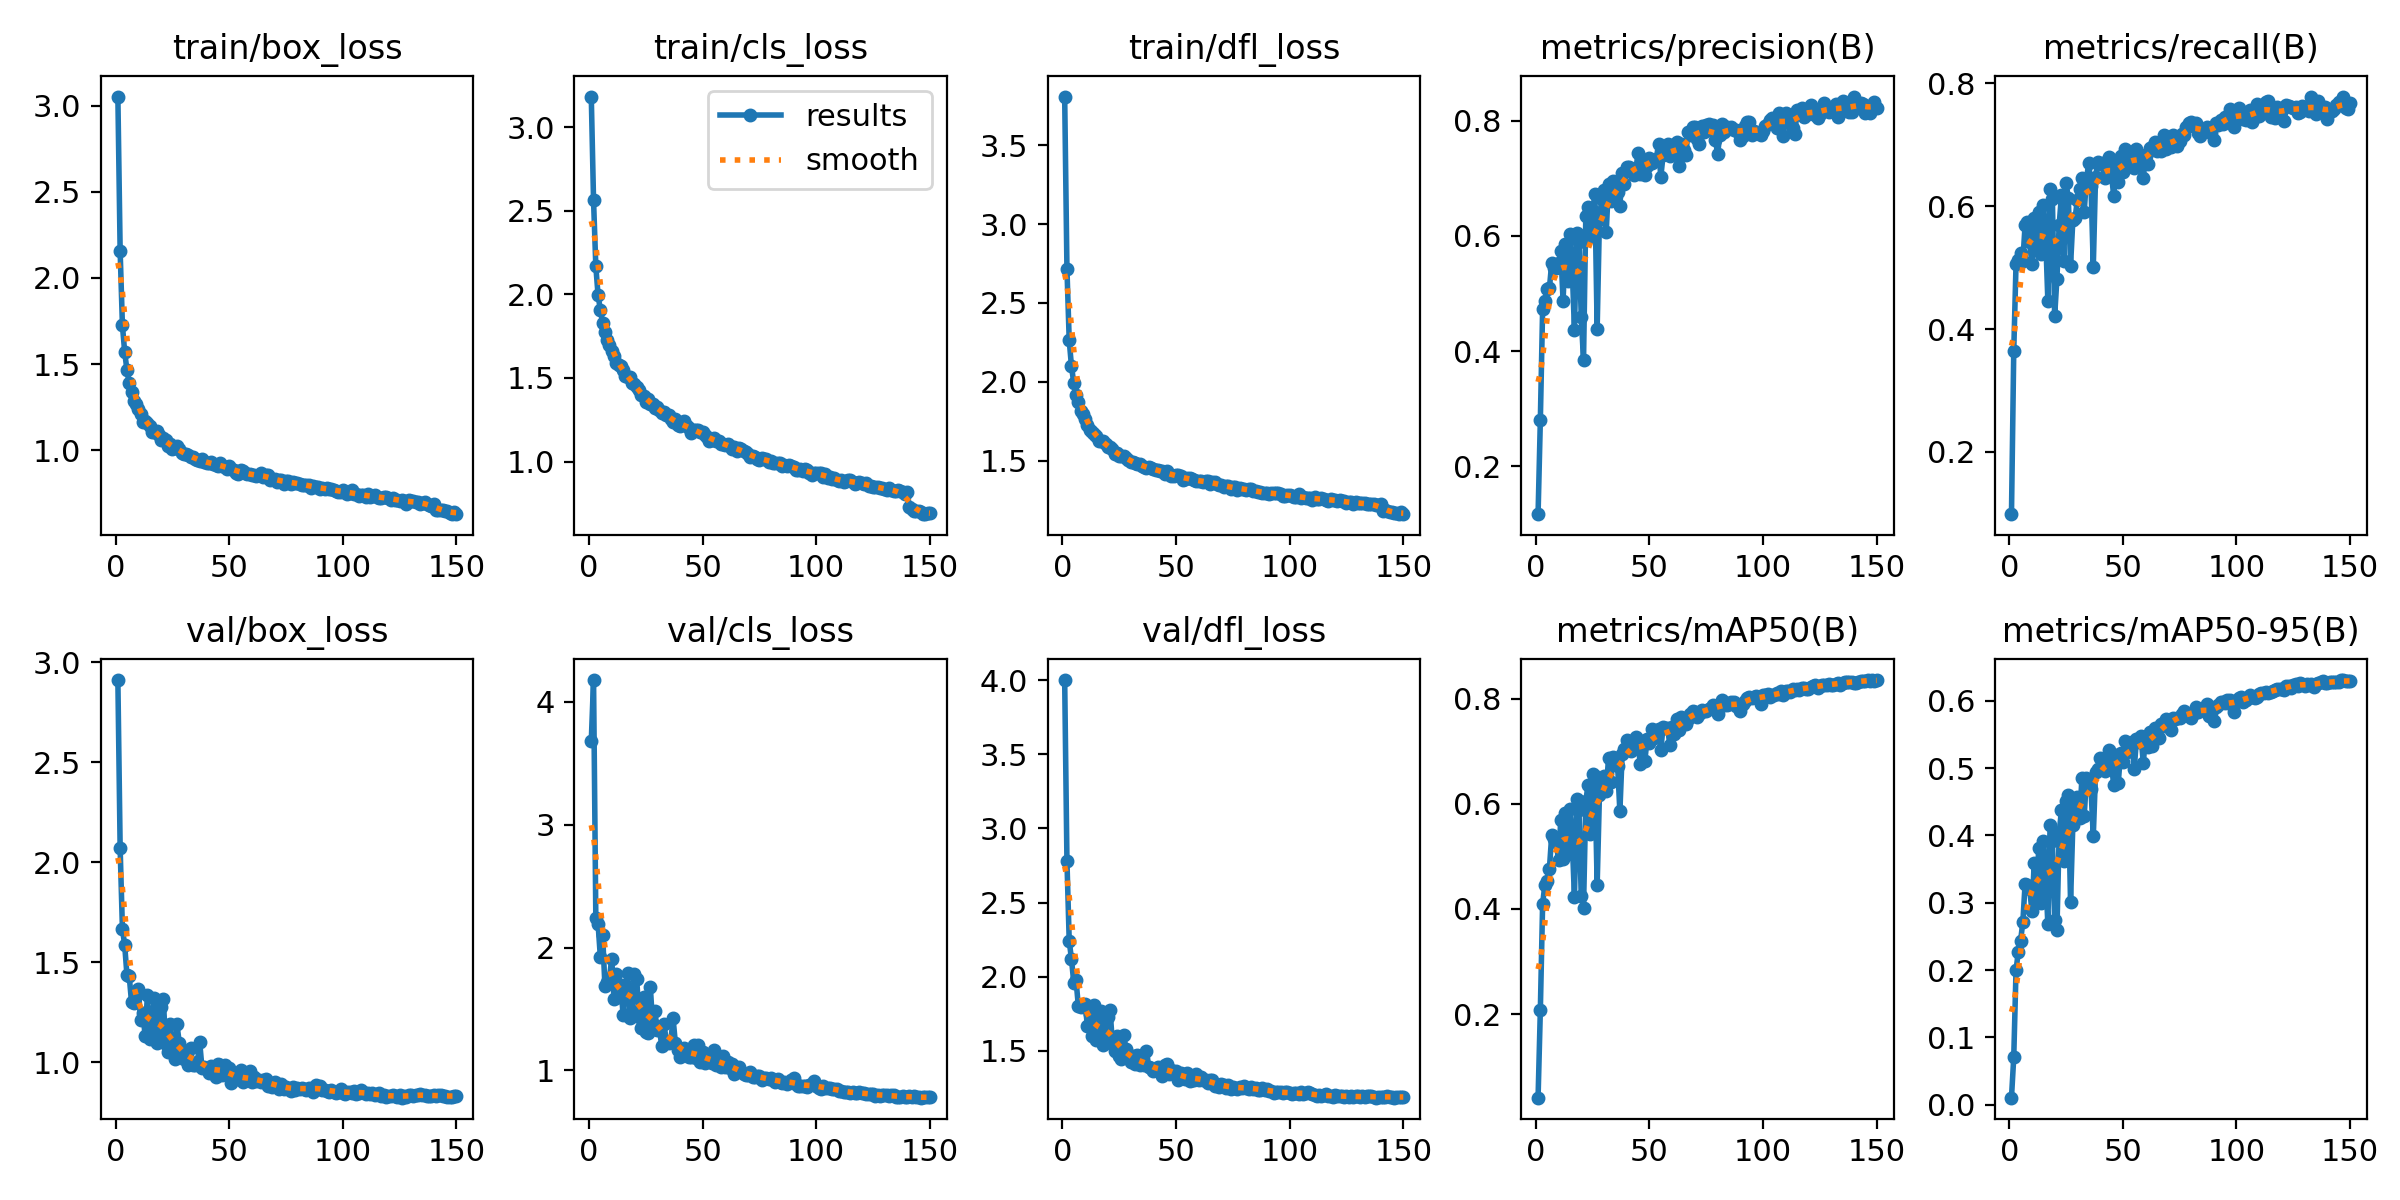

In [ ]:
from IPython.display import Image, display
import glob

result_path = glob.glob('/content/runs/detect/ngawasin-scratch/results.png')
if result_path:
    display(Image(result_path[0], width=900))
else:
    print('File results.png tidak ditemukan.')

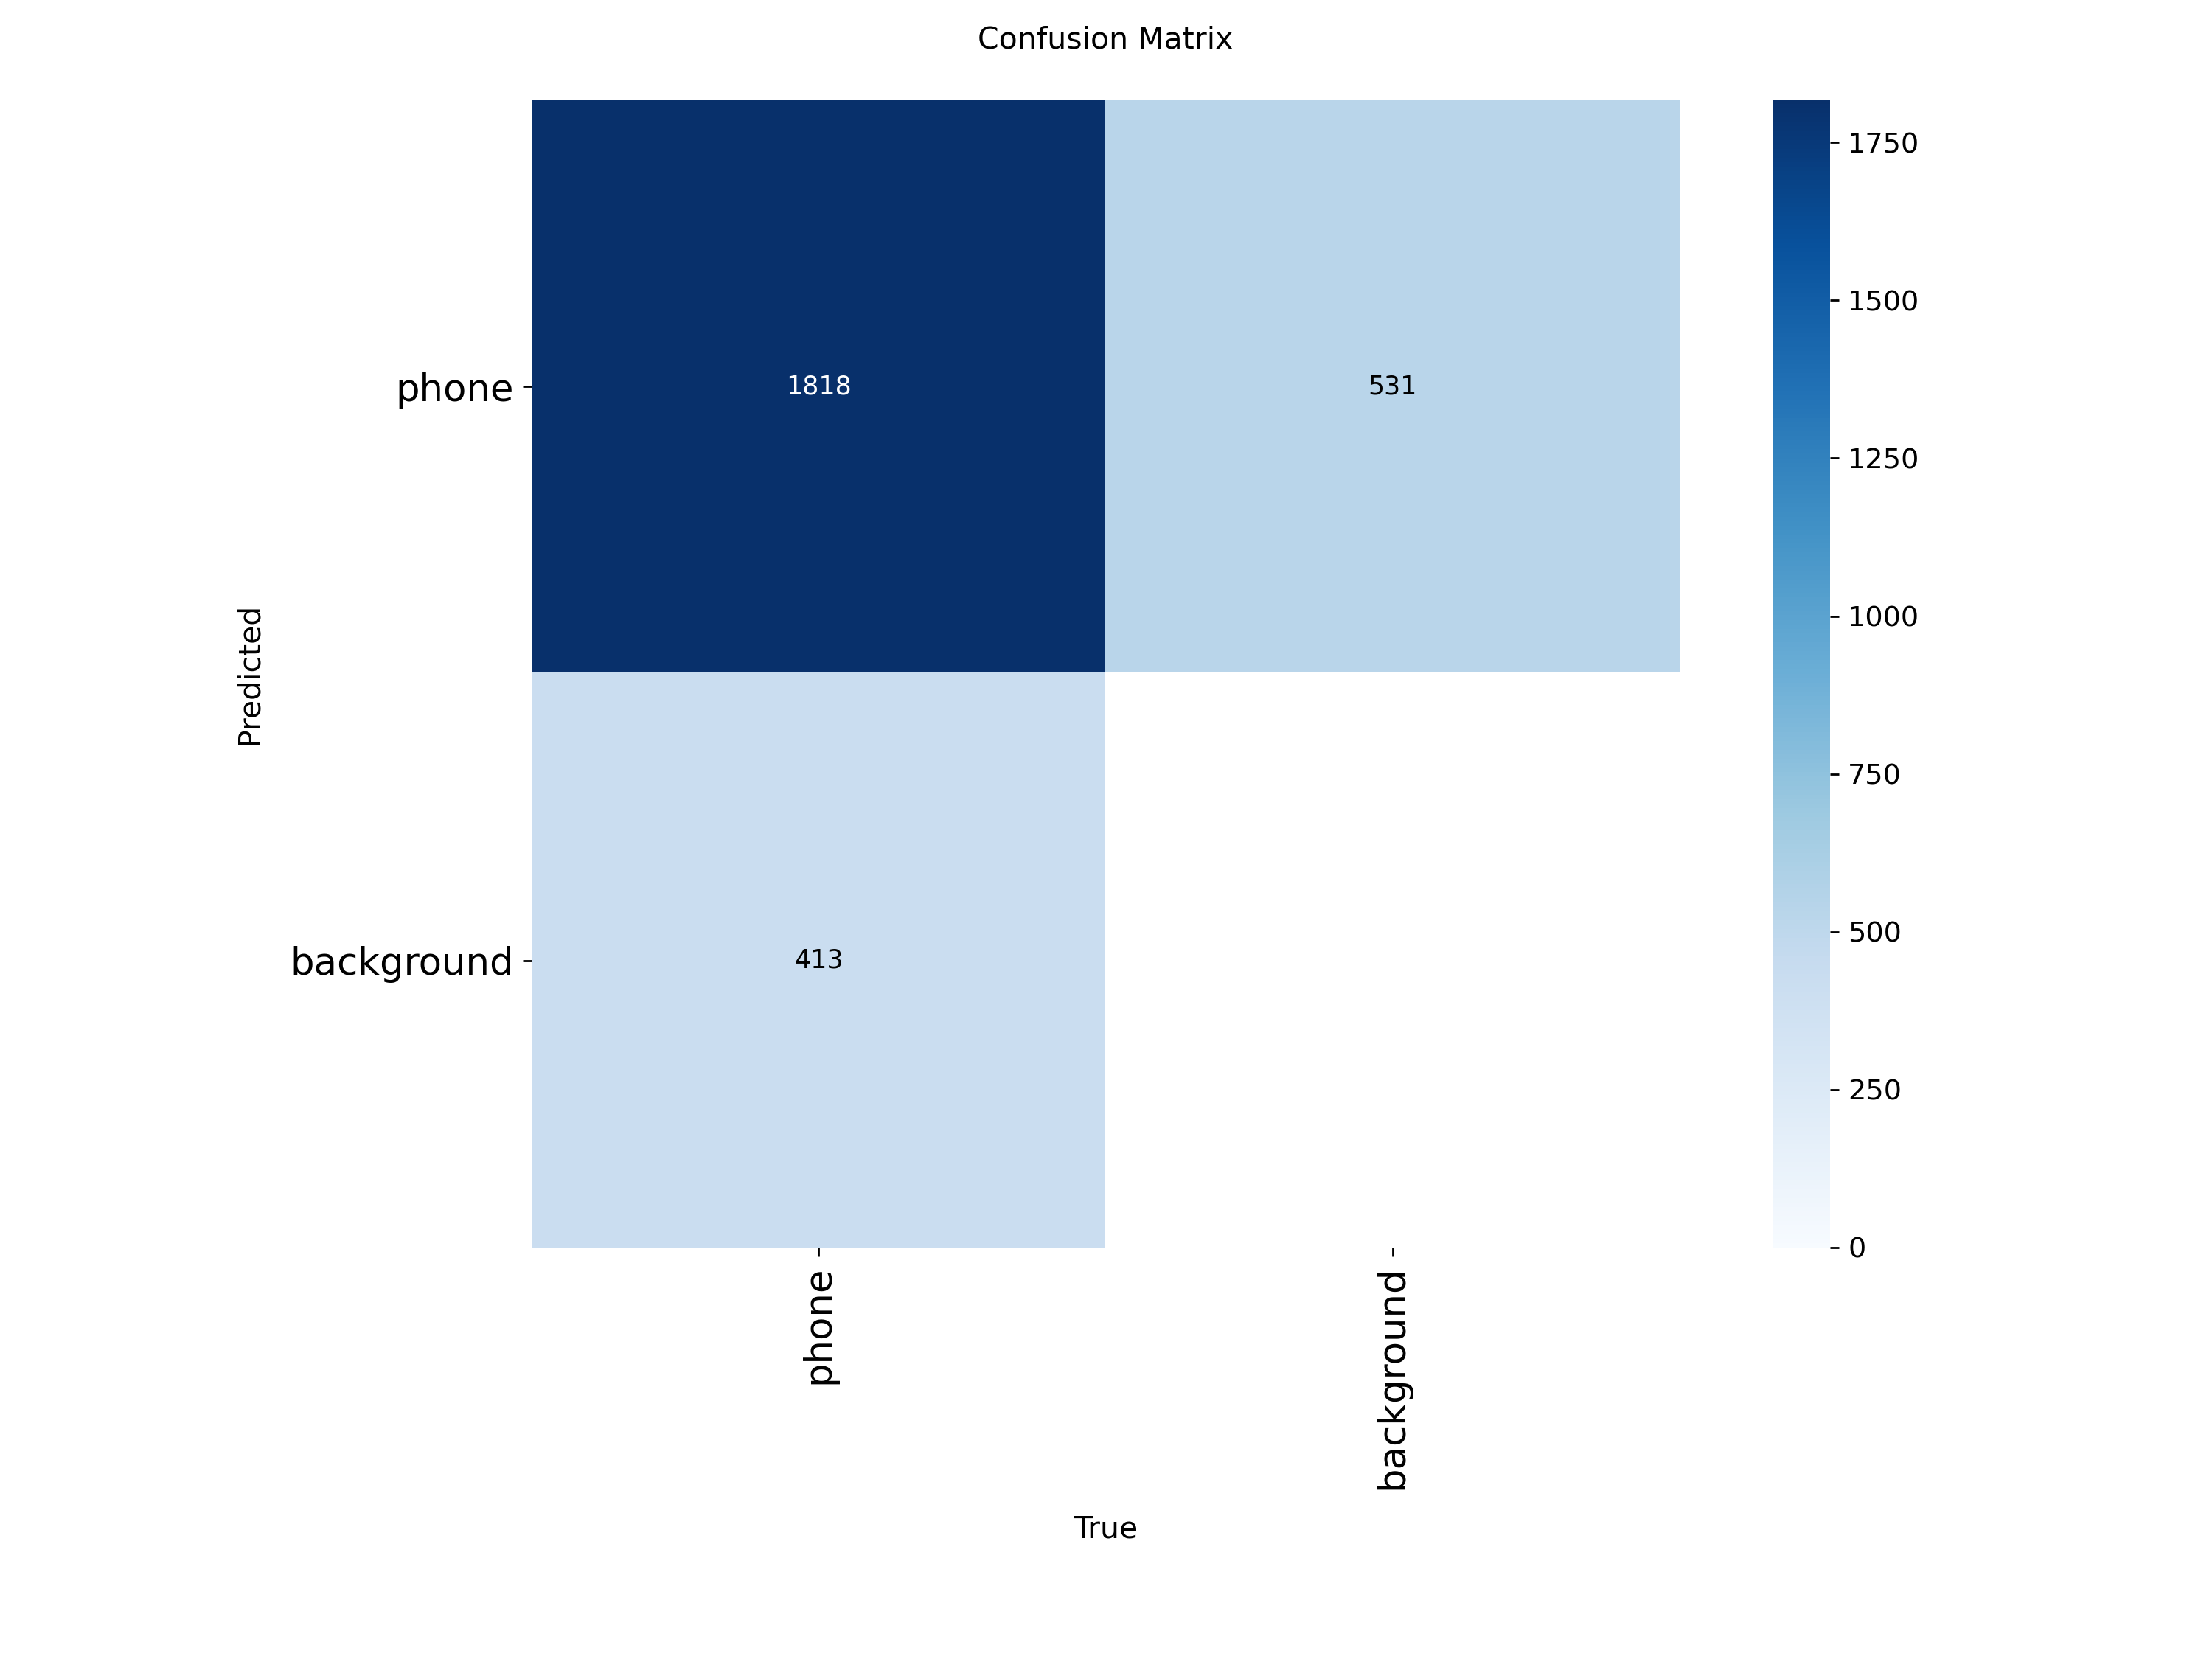

In [ ]:
cm_path = glob.glob('/content/runs/detect/ngawasin-scratch/confusion_matrix.png')
if cm_path:
    display(Image(cm_path[0], width=600))

# **Evaluasi Model**

In [ ]:
from ultralytics import YOLO

best_model = YOLO('/content/runs/detect/ngawasin-scratch/weights/best.pt')

metrics = best_model.val(data='/content/dataset/data.yaml', split='test')

print('Hasil Evaluasi Model:')
print(f'  Precision : {metrics.box.p[0]:.1%}')
print(f'  Recall    : {metrics.box.r[0]:.1%}')
print(f'  mAP@0.5   : {metrics.box.map50:.1%}')

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 493.0±175.7 MB/s, size: 10.6 KB)
val: Scanning /content/dataset/test/labels... 328 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 328/328 2.1Kit/s 0.2s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 4.8it/s 4.4s
                   all        328       1051      0.794      0.761      0.811      0.602
Speed: 2.1ms preprocess, 4.2ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val
Hasil Evaluasi Model:
  Precision : 79.4%
  Recall    : 76.1%
  mAP@0.5   : 81.1%


# **Download Model**


In [ ]:
import shutil
from google.colab import files

shutil.copy(
    '/content/runs/detect/ngawasin-scratch/weights/best.pt',
    '/content/dataTRAINING.pt'
)

files.download('/content/dataTRAINING.pt')
print('Download dataTRAINING.pt selesai.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download dataTRAINING.pt selesai.
